# Vergleich von SFT vs. DPO (w_style=1.0, w_sem=0.0) auf dem Lebenshilfe-Datensatz
### Masterarbeit: Automatische Übersetzung von Alltagssprache (AS) in Leichte Sprache (LS)

Dieses Notebook vergleicht das Supervised Fine-Tuned (SFT) Basismodell mit dem Direct Preference Optimization (DPO) Modell aus der Konfiguration **2_dpo_w10_w00_final** (Non-Trainer).

### Forschungsfrage:
Steigert das DPO-Tuning die Leistung (insb. die Einfachheit/Leichte Sprache) signifikant, oder reicht das reine SFT-Training bereits aus? Welche Trade-offs entstehen bezüglich des Semantikerhalts (w_style=1.0, w_sem=0.0)?

In [1]:
# ==============================================================================
# ZENTRALE KONFIGURATION & PARAMS
# ==============================================================================
LH_DATASET_PATH = "data/lebenshilfe/lebenshilfe_dataset.json"
SYNTHETIC_MODEL_PATH = "results/models/bilstm_synthetic_regression.pt"
SYNTHETIC_VOCAB_PATH = "data/vocabs/synthetic_vocab.json"
SBERT_MODEL_NAME = "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"

MAX_SOURCE_LEN = 256
MAX_TARGET_LEN = 256
MAX_SAMPLES = 49  # Anzahl der zu evaluierenden Sätze

# Pfade zu den Modellen
SFT_MODEL_PATH = "results/models/best_sft_w10_w00_final_temp.pt"
DPO_MODEL_PATH = "results/models/seq2seq_dpo_w10_w00_final"

In [2]:
import os
import sys

# Arbeitsverzeichnis auf das Root-Verzeichnis setzen
while not os.path.exists(".git"):
    parent = os.path.dirname(os.getcwd())
    if parent == os.getcwd():
        break
    os.chdir("..")

print("Aktuelles Arbeitsverzeichnis:", os.getcwd())
print("Existiert der data-Ordner hier?", os.path.exists("data"))

Aktuelles Arbeitsverzeichnis: /home/fiete/master-thesis
Existiert der data-Ordner hier? True


In [3]:
import json
import glob
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import spacy
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from transformers import MBartForConditionalGeneration, MBart50TokenizerFast
from sentence_transformers import SentenceTransformer, util

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Nutze Device:", DEVICE)

Nutze Device: cuda


## 1. Laden des Simplicity-Modells (BiLSTM Synthetic Regressor)
Dieses Modell bewertet den Grad der Leichten Sprache ($R_{\text{style}}$).

In [4]:
class BiLSTMRegressor(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, dropout=0.3):
        super(BiLSTMRegressor, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, 1)
        self.dropout = nn.Dropout(dropout)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        _, (hidden, _) = self.lstm(embedded)
        hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        out = self.fc(self.dropout(hidden))
        return self.sigmoid(out)

with open(SYNTHETIC_VOCAB_PATH, "r", encoding="utf-8") as f:
    vocab_data = json.load(f)
    synthetic_stoi = vocab_data.get("stoi", vocab_data)

bilstm_model = BiLSTMRegressor(len(synthetic_stoi), embed_dim=128, hidden_dim=128)
if os.path.exists(SYNTHETIC_MODEL_PATH):
    bilstm_model.load_state_dict(torch.load(SYNTHETIC_MODEL_PATH, map_location="cpu"))
    bilstm_model.to("cpu")
    bilstm_model.eval()
    print(f"BiLSTM Synthetic Regressor geladen von {SYNTHETIC_MODEL_PATH}")
else:
    print(f"Warnung: {SYNTHETIC_MODEL_PATH} nicht gefunden.")

nlp = spacy.load("de_core_news_sm", disable=["ner", "tagger", "lemmatizer"])

def predict_simplicity_score(texts):
    scores = []
    unk_idx = synthetic_stoi.get("<unk>") or synthetic_stoi.get("<UNK>") or 1
    for text in texts:
        doc = nlp(text)
        tokens = [t.text.lower() for t in doc if not t.is_space]
        indices = [synthetic_stoi.get(t, unk_idx) for t in tokens[:150]]
        if len(indices) == 0:
            indices = [0]
        inp_tensor = torch.tensor([indices], dtype=torch.long, device="cpu")
        with torch.no_grad():
            score = bilstm_model(inp_tensor).item()
        scores.append(score)
    return np.array(scores)

BiLSTM Synthetic Regressor geladen von results/models/bilstm_synthetic_regression.pt


## 2. Laden des SBERT-Modells & Definition der Metriken
Zur Bewertung des Semantikerhalts ($R_{\text{sem}}$).

In [5]:
sbert_model = SentenceTransformer(SBERT_MODEL_NAME, device="cpu")

def predict_semantic_similarity(source_texts, generated_texts):
    emb_src = sbert_model.encode(source_texts, convert_to_tensor=True)
    emb_gen = sbert_model.encode(generated_texts, convert_to_tensor=True)
    cosine_sims = util.cos_sim(emb_src, emb_gen).diagonal().cpu().numpy()
    return cosine_sims

class CompositeRewardEvaluator:
    def __init__(self, w_style=0.5, w_sem=0.5):
        self.w_style = w_style
        self.w_sem = w_sem
        
    def compute_reward(self, source_texts, generated_texts):
        r_style = predict_simplicity_score(generated_texts)
        r_sem = predict_semantic_similarity(source_texts, generated_texts)
        r_sem_norm = np.clip((r_sem + 1.0) / 2.0, 0.0, 1.0)
        total_reward = self.w_style * r_style + self.w_sem * r_sem_norm
        return total_reward, r_style, r_sem_norm

# Standardisierte Evaluierung (w_style=0.5, w_sem=0.5)
reward_evaluator = CompositeRewardEvaluator(w_style=0.5, w_sem=0.5)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

## 3. Laden des Lebenshilfe-Datensatzes

In [6]:
with open(LH_DATASET_PATH, "r", encoding="utf-8") as f:
    lh_data = json.load(f)
print(f"Lebenshilfe Datensatz geladen: {len(lh_data)} Artikel-Paare.")

Lebenshilfe Datensatz geladen: 49 Artikel-Paare.


## 4. Evaluierungsfunktion für SFT und DPO Modelle
Das SFT-Modell wird durch Initialisieren von `mbart-large-50` und Laden der Gewichte aus der `.pt`-Datei geladen.
Das DPO-Modell wird als fertiger HuggingFace-Ordner geladen.

In [7]:
def evaluate_model(model_name, model_path, lh_data, max_samples=49):
    if not os.path.exists(model_path):
        print(f"Warnung: Modell-Pfad {model_path} existiert nicht. Überspringe.")
        return None, None
        
    print(f"Lade {model_name}-Modell von: {model_path}...")
    
    if "sft" in model_name.lower():
        # SFT: Lade das Basis-Modell und füge den State Dict hinzu
        tokenizer = MBart50TokenizerFast.from_pretrained("facebook/mbart-large-50")
        model = MBartForConditionalGeneration.from_pretrained("facebook/mbart-large-50").to(DEVICE)
        model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    else:
        # DPO: Lade direkt aus dem exportierten HuggingFace-Ordner
        tokenizer = MBart50TokenizerFast.from_pretrained(model_path)
        model = MBartForConditionalGeneration.from_pretrained(model_path).to(DEVICE)
        
    model.eval()
    
    as_texts = [item["as_text"] for item in lh_data[:max_samples]]
    ls_ref_texts = [item["ls_text"] for item in lh_data[:max_samples]]
    
    batch_size = 16
    gen_texts = []
    for i in range(0, len(as_texts), batch_size):
        batch_src = as_texts[i:i+batch_size]
        prompts = ["Übersetze in Leichte Sprache: " + t for t in batch_src]
        inputs = tokenizer(prompts, padding=True, truncation=True, max_length=MAX_SOURCE_LEN, return_tensors="pt").to(DEVICE)
        with torch.no_grad():
            outputs = model.generate(
                input_ids=inputs["input_ids"],
                attention_mask=inputs["attention_mask"],
                max_length=MAX_TARGET_LEN,
                num_beams=4,
                repetition_penalty=2.5,
                no_repeat_ngram_size=3,
                early_stopping=True
            )
        decoded = tokenizer.batch_decode(outputs, skip_special_tokens=True)
        gen_texts.extend(decoded)
        
    tot_reward, r_style, r_sem = reward_evaluator.compute_reward(as_texts, gen_texts)
    sim_to_ref = predict_semantic_similarity(ls_ref_texts, gen_texts)
    sim_to_ref_norm = np.clip((sim_to_ref + 1.0) / 2.0, 0.0, 1.0)
    
    # Speicher freigeben
    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        
    summary = {
        "r_style": r_style.mean(),
        "r_sem_as": r_sem.mean(),
        "sim_ref": sim_to_ref_norm.mean(),
        "reward_05_05": tot_reward.mean()
    }
    
    details = pd.DataFrame({
        "as_text": as_texts,
        "ls_reference": ls_ref_texts,
        "translation": gen_texts,
        "r_style": r_style,
        "r_sem_as": r_sem,
        "sim_ref": sim_to_ref_norm,
        "reward_05_05": tot_reward
    })
    
    return summary, details

## 5. Durchführung der Evaluierung

In [8]:
results_summary = {}
results_details = {}

models_to_evaluate = {
    "SFT Model (Base)": (SFT_MODEL_PATH),
    "DPO Model (w_style=1.0, w_sem=0.0)": (DPO_MODEL_PATH)
}

for name, path in models_to_evaluate.items():
    summary, details = evaluate_model(name, path, lh_data, max_samples=MAX_SAMPLES)
    if summary is not None:
        results_summary[name] = summary
        results_details[name] = details

Lade SFT Model (Base)-Modell von: results/models/best_sft_w10_w00_final_temp.pt...


Loading weights:   0%|          | 0/519 [00:00<?, ?it/s]

Lade DPO Model (w_style=1.0, w_sem=0.0)-Modell von: results/models/seq2seq_dpo_w10_w00_final...


Loading weights:   0%|          | 0/516 [00:00<?, ?it/s]

## 6. Vergleichstabelle

In [9]:
df_summary = pd.DataFrame(results_summary).T
df_summary.columns = [
    "Ø Simplicity (R_style)",
    "Ø Sem-Sim to AS (R_sem)",
    "Ø Sem-Sim to LS Reference",
    "Ø Composite Reward (0.5/0.5)"
]
print("=== COMPARISON: SFT vs. DPO (w_style=1.0, w_sem=0.0) ===")
display(df_summary.round(4))

=== COMPARISON: SFT vs. DPO (w_style=1.0, w_sem=0.0) ===


,Ø Simplicity (R_style),Ø Sem-Sim to AS (R_sem),Ø Sem-Sim to LS Reference,Ø Composite Reward (0.5/0.5)
SFT Model (Base),0.9061,0.8681,0.8368,0.8871
"DPO Model (w_style=1.0, w_sem=0.0)",0.9345,0.8689,0.8383,0.9017


## 7. Visualisierung des Vergleichs

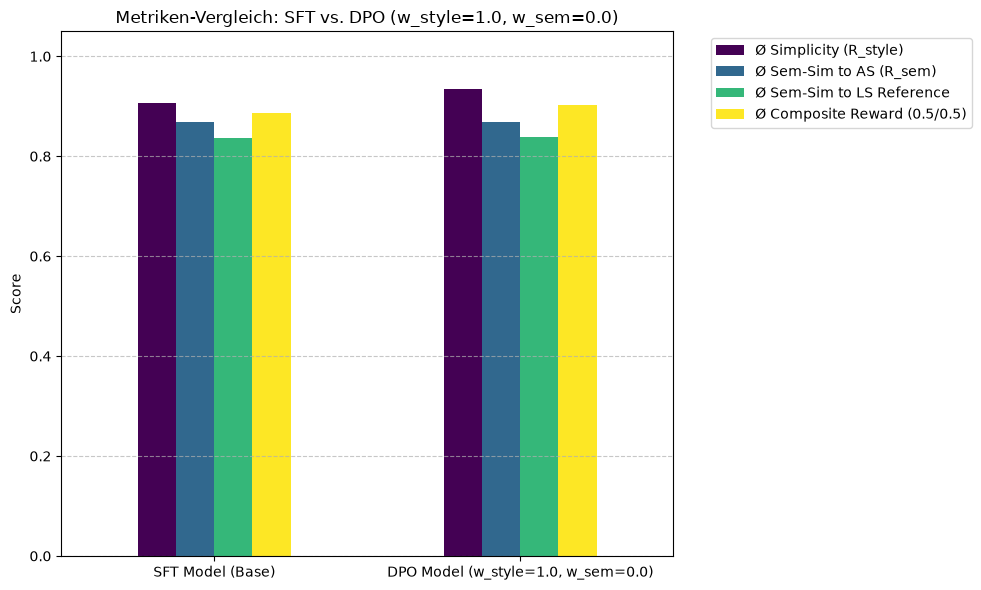

In [10]:
if len(df_summary) > 0:
    ax = df_summary.plot(kind="bar", figsize=(10, 6), rot=0, colormap="viridis")
    plt.title("Metriken-Vergleich: SFT vs. DPO (w_style=1.0, w_sem=0.0)")
    plt.ylabel("Score")
    plt.ylim(0, 1.05)
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

## 8. Qualitative Analyse und Beispiele
Hier betrachten wir konkrete Beispielsätze und deren Übersetzungen durch beide Modelle.

In [11]:
if "SFT Model (Base)" in results_details and "DPO Model (w_style=1.0, w_sem=0.0)" in results_details:
    sft_det = results_details["SFT Model (Base)"]
    dpo_det = results_details["DPO Model (w_style=1.0, w_sem=0.0)"]
    
    # Zeige 3 zufällige oder exemplarische Sätze
    indices = [0, 1, 2]
    for idx in indices:
        print(f"\n--- BEISPIEL {idx+1} ---")
        print(f"ALLTAGSSPRACHE (AS):\n{sft_det.loc[idx, 'as_text']}\n")
        print(f"REFERENZ (LS):\n{sft_det.loc[idx, 'ls_reference']}\n")
        print(f"SFT ÜBERSETZUNG:\n{sft_det.loc[idx, 'translation']}")
        print(f"  -> Simplicity Score: {sft_det.loc[idx, 'r_style']:.4f}")
        print(f"  -> Sem-Sim to AS: {sft_det.loc[idx, 'r_sem_as']:.4f}\n")
        print(f"DPO ÜBERSETZUNG:\n{dpo_det.loc[idx, 'translation']}")
        print(f"  -> Simplicity Score: {dpo_det.loc[idx, 'r_style']:.4f}")
        print(f"  -> Sem-Sim to AS: {dpo_det.loc[idx, 'r_sem_as']:.4f}")
        print("="*80)


--- BEISPIEL 1 ---
ALLTAGSSPRACHE (AS):
Presseinformation von CAU und StK
3.12.2024
xxx/2024
„Inklusion im Fokus“: Aktionstag an der CAU bringt alle zusammen

Ministerpräsident Daniel Günther eröffnet Veranstaltung mit Filmpremiere „Das ist Leben - einzigartig vielfältig“

Der 3. Dezember ist der internationale Tag der Menschen mit Behinderungen. Zu diesem Anlass hatte die Christian-Albrechts-Universität zu Kiel (CAU) gemeinsam mit der Landesregierung zum Aktionstag „Inklusion im Fokus“ im Kieler Wissenschaftszentrum eingeladen. Über 100 Gäste aus Bildung, Hochschulen und Politik kamen, um über Inklusion und Teilhabe zu diskutieren.

Ministerpräsident Daniel Günther sagte zur Begrüßung: „Gelebte Inklusion ist die Voraussetzung für eine vielfältige, gleichberechtigte Gesellschaft. Die Landesregierung hat in diesem Bereich schon viel auf den Weg gebracht. Aber Inklusionsprozesse benötigen Zeit, und es gibt noch viel zu tun. Umso mehr freue ich mich über den Film, der anschaulich über di